## Wczytanie embeddingów

In [6]:
import numpy as np
import pandas as pd

# embeddings zapisane wcześniej
X_pca = np.load("../artifacts/plant_embeddings.npy")


# metadane roślin
df = pd.read_csv("../data/plants_clean_final.csv")
print("X_pca shape:", X_pca.shape)


X_pca shape: (159, 10)


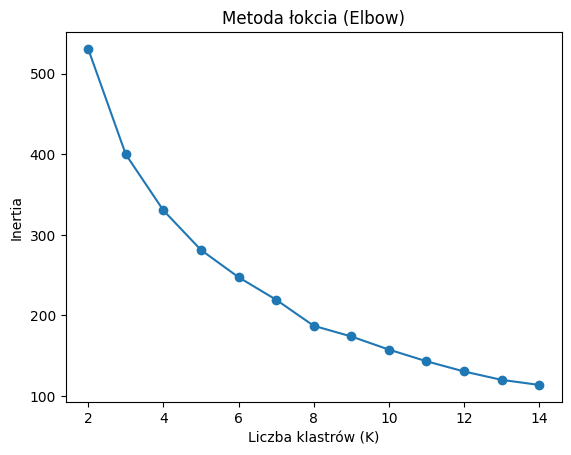

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

K_range = range(2, 15)
inertias = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_pca)  # X_pca: embedding 10D (n, 10)
    inertias.append(km.inertia_)

plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Liczba klastrów (K)")
plt.ylabel("Inertia")
plt.title("Metoda łokcia (Elbow)")
plt.show()


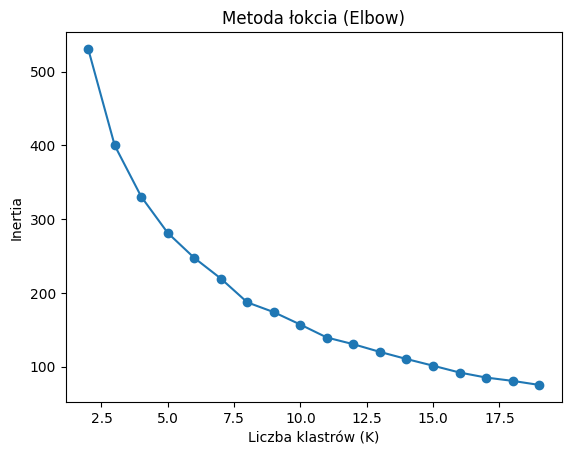

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

K_range = range(2, 20)
inertias = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=15, random_state=42)
    km.fit(X_pca)  # X_pca: embedding 10D (n, 10)
    inertias.append(km.inertia_)

plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Liczba klastrów (K)")
plt.ylabel("Inertia")
plt.title("Metoda łokcia (Elbow)")
plt.show()


### Notatka — obserwacje KMeans

- **Metoda łokcia (Elbow):** krzywa spada gwałtownie do K≈6, potem wypłaszcza się.  
  Nie ma wyraźnego ostrego łokcia, ale lekkie załamanie widoczne przy K=7–8.  

- **Zakres testowany:** początkowo K=2–14, następnie zwiększono zakres do K=20,  
  ale mimo tego wyraźny łokieć nadal się nie pojawił.  

- **Interpretacja:**  
  - Dla K<6 klastry są zbyt ogólne.  
  - Powyżej K≈8 poprawa jest niewielka (inertia maleje wolniej).  
  - Kandydaci: K=7 albo K=8.  

- **Dalsze kroki:**  
  - policzyć **Silhouette Score** dla 2–10 klastrów,  
  - sprawdzić wizualizację PCA 2D z kolorami dla K=7 i K=8,  
  - wybrać wartość, która da zarówno sensowne klastry, jak i prostą interpretację biznesową (czytelne segmenty roślin).  

👉 Wniosek: najbardziej obiecujące wydają się **K=7–8**, ale wymaga to potwierdzenia silhouette score i interpretacji klastrów.


K=2, silhouette=0.449
K=3, silhouette=0.451
K=4, silhouette=0.295
K=5, silhouette=0.328
K=6, silhouette=0.310
K=7, silhouette=0.336
K=8, silhouette=0.392
K=9, silhouette=0.391
K=10, silhouette=0.428
K=11, silhouette=0.424
K=12, silhouette=0.451
K=13, silhouette=0.465
K=14, silhouette=0.485
K=15, silhouette=0.478
K=16, silhouette=0.501
K=17, silhouette=0.524
K=18, silhouette=0.534
K=19, silhouette=0.535
K=20, silhouette=0.554


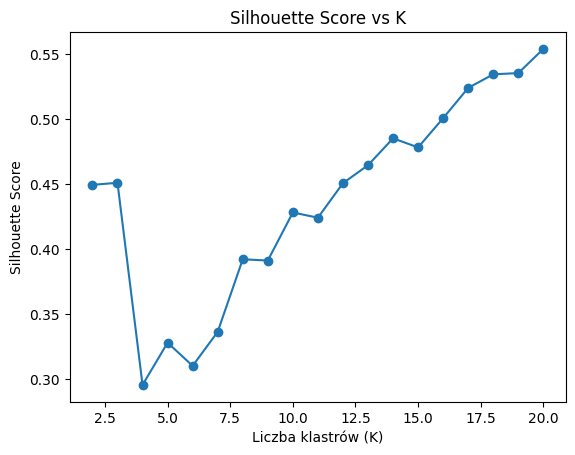

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K_range = range(2, 21)
scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    scores.append(sil)
    print(f"K={k}, silhouette={sil:.3f}")

# wykres
plt.plot(list(K_range), scores, marker="o")
plt.xlabel("Liczba klastrów (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()


### Notatka — Silhouette Score (ocena KMeans)

- **Wyniki:**  
  - K=2–5 → silhouette niski (0.29–0.45) → klastry mało wyraźne.  
  - K≈8–12 → poprawa, wartości 0.39–0.45 (średnia jakość).  
  - K=13–20 → dalsza poprawa, najlepsze wyniki przy K=18–20 (0.53–0.55).  

- **Technicznie:** optimum silhouette znajduje się przy **K=20 (0.554)**.  
- **Praktycznie:** 18–20 klastrów jest trudne do interpretacji biznesowej (za dużo grup).  
- **Kompromis:** sensowne wydaje się **K≈8–10**, gdzie silhouette jest umiarkowanie dobry (~0.39–0.43), ale klastry można łatwiej opisać i używać w aplikacji.

👉 **Wniosek:** najlepsza jakość klastrów technicznie przy K=20, ale na potrzeby aplikacji rekomendowane K≈10 (balans między jakością a interpretowalnością).


In [20]:
import joblib

# wybieramy K na podstawie Elbow/Silhouette i biznesowej interpretacji
best_k = 10
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# dopisujemy do dataframe
df["cluster"] = clusters
print(df[["latin", "category_group", "cluster"]].head())

# zapis modelu
joblib.dump(kmeans, "../artifacts/kmeans.pkl")
print(f"✔ Model KMeans zapisany → artifacts/kmeans.pkl (K={best_k})")


                          latin            category_group  cluster
0        Aeschynanthus lobianus                   Wisząca        0
1            Adiantum raddianum  Paproć / roślina zielona        5
2              Aechmea fatsiata          Roślina kwitnąca        6
3  Agave angustilolia Marginata         Sukulent / kaktus        8
4                Aechmea ramosa          Roślina kwitnąca        6
✔ Model KMeans zapisany → artifacts/kmeans.pkl (K=10)


In [21]:
# liczebność w kazdym klastrze

print(df["cluster"].value_counts())


cluster
4    25
0    24
6    24
7    21
1    15
2    13
3    12
5    11
9     8
8     6
Name: count, dtype: int64


In [22]:
# rozkład kategorii w klastrach

pd.crosstab(df["cluster"], df["category_group"])


category_group,Inne,Palma / drzewko ozdobne,Paproć / roślina zielona,Roślina kwitnąca,Sukulent / kaktus,Wisząca
cluster,,,,,,
0,4,1,8,10,0,1
1,1,1,4,0,8,1
2,0,1,6,1,1,4
3,0,12,0,0,0,0
4,2,6,14,2,0,1
5,1,1,9,0,0,0
6,0,0,11,7,0,6
7,1,11,3,6,0,0
8,0,0,0,0,6,0


🔎 Obserwacje:

Cluster 3 → praktycznie czysta grupa Palma / drzewko ozdobne (12 sztuk).

Cluster 8 → czysty klaster Sukulenty/kaktusy (6 sztuk).

Cluster 9 → czysty klaster Rośliny kwitnące (8 sztuk).

Cluster 5 → prawie czysty klaster Paprocie (9 sztuk).

Cluster 7 → mocny udział Palmy (11) + trochę kwitnących (6).

Clustery 0, 2, 4, 6 → mieszanki różnych kategorii, ale i tak widać przewagę pewnych typów (np. 6 → dużo paproci i wiszących, 4 → dużo paproci).

👉 KMeans sensownie wyłapał naturalne grupy (np. palmy, sukulenty, paprocie, kwitnące), a w niektórych klastrach zebrał trochę bardziej mieszane rośliny.

✅ Wniosek :

Interpretowalność jest dobra: część klastrów da się wprost nazwać („klaster palm”, „klaster sukulentów”, „klaster paproci”).

To wystarczy, żeby w aplikacji pokazywać rekomendacje w stylu:
„Ta roślina jest w grupie sukulentów – podobne do niej są: …”.

Klastery mieszane można traktować jako „łączące cechy” (np. paprocie + wiszące).

In [23]:
# Cosine similarity (top-N)
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# macierz podobieństw
sim_matrix = cosine_similarity(X_pca)

def top_n_similar(latin_name, n=5):
    idx = df.index[df["latin"] == latin_name].tolist()[0]
    sims = sim_matrix[idx]
    similar_idx = np.argsort(-sims)
    similar_idx = [i for i in similar_idx if i != idx][:n]
    return df.loc[similar_idx, ["latin", "category_group"]].assign(similarity=sims[similar_idx].round(3))

# test
print(top_n_similar("Aeschynanthus lobianus", n=5))

                   latin           category_group  similarity
85       Licuala spinosa  Palma / drzewko ozdobne       0.829
140  Tillandsia Creation         Roślina kwitnąca       0.802
138    Tillandsia cyanea         Roślina kwitnąca       0.802
139   Vriesea Christiane         Roślina kwitnąca       0.802
132    Vriesea splendens         Roślina kwitnąca       0.802


### Notatka — Cosine similarity jako silnik rekomendacji

- **Mechanizm:** Cosine similarity porównuje wektory embeddingów PCA (10D).  
  - 1.0 = identyczne rośliny  
  - 0 = brak podobieństwa  

- **Wynik testu (Aeschynanthus lobianus):**  
  - Najbliżej znalazły się inne rośliny kwitnące (*Tillandsia*, *Vriesea*),  
  - Dodatkowo palma (*Licuala spinosa*), co sugeruje podobieństwo w cechach środowiskowych.  

- **Interpretacja:**  
  - Silnik rekomendacji działa poprawnie – zwraca gatunki o zbliżonych wymaganiach.  
  - Sporadyczne „mieszanki” (np. palma w grupie kwitnących) są naturalnym efektem PCA i świadczą o podobnych warunkach hodowlanych.  

👉 **Wniosek:** Cosine similarity na embeddingach PCA pełni rolę podstawowego modułu rekomendacji w Plantelligence.


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

# ścieżki
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True, parents=True)

# wczytanie danych
df = pd.read_csv("house_plants_features.csv")
pca_embeddings = np.load(ARTIFACTS_DIR / "plant_embeddings.npy")
kmeans = joblib.load(ARTIFACTS_DIR / "kmeans.pkl")

# dodanie kolumn PCA i numerów klastrów
pca_cols = [f"PC{i+1}" for i in range(pca_embeddings.shape[1])]
df_pca = pd.DataFrame(pca_embeddings, columns=pca_cols)
df["cluster"] = kmeans.labels_

# połączenie danych
clusters_df = pd.concat([df[["latin", "category_group", "cluster"]], df_pca], axis=1)

# zapis
clusters_df.to_csv(ARTIFACTS_DIR / "clusters.csv", index=False)
print("✅ Zapisano:", ARTIFACTS_DIR / "clusters.csv")
print("📊 Kształt danych:", clusters_df.shape)
print(clusters_df.head())
